In [26]:
import os
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Iterable, Any
from dataclasses import dataclass
import re
import torch
import pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import json
# Add project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))


from src.data_loader.ieee_phm.IEEEPHMDataLoader import build_dataloaders
from src.data_loader.ieee_phm.DataConfig import DataConfig

from src.models.ieee_phm.TransformerModel import TransformerModel

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"Project root: {project_root}")
print("Libraries imported successfully.")

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
Libraries imported successfully.


In [27]:
PROCESSED_DIR = project_root / "data" / "processed" / "ieee_phm"
OUTPUT_DIR = project_root / "outputs" / "ieee_phm_bearing"
SAVE_MODEL_DIR = OUTPUT_DIR / "saved_models"

print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model save directory: {SAVE_MODEL_DIR}")

Processed data directory: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/processed/ieee_phm
Output directory: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing
Model save directory: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/saved_models


In [28]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [29]:
def load_preprocessed_data() -> Tuple[dict, dict, List[str], DataConfig, dict]:
    """Load the cleaned bearing data from the pickle saved during EDA/preprocessing."""
    pkl_path = PROCESSED_DIR / "cleaned_bearing_data.pkl"
    with open(pkl_path, "rb") as f:
        data_dict = pickle.load(f)

    cleaned_train = data_dict["train"]
    cleaned_test = data_dict["test"]
    feature_cols = data_dict["feature_cols"]
    config = data_dict["config"]
    metadata = data_dict["metadata"]
    return cleaned_train, cleaned_test, feature_cols, config, metadata


def load_dataloaders() -> Tuple[DataLoader, DataLoader, DataLoader, Any, Dict, List[str]]:
    """Build train / val / test loaders and return all info needed for training."""
    cleaned_train, cleaned_test, feature_cols, config, _ = load_preprocessed_data()

    train_loader, val_loader, test_loader, normalizer, metadata = build_dataloaders(
        cleaned_train, cleaned_test, feature_cols, config
    )
    return train_loader, val_loader, test_loader, normalizer, metadata, feature_cols


def build_preprocess_dict(
    feature_cols: List[str],
    metadata: Dict[str, Any],
    normalizer: Any,
) -> Dict[str, Any]:
    """
    Assemble a `preprocess` dict that the generic Trainer can embed in checkpoints.
    This mirrors the structure used by train_cmapss.py so that downstream code
    (evaluation, counterfactual generation) can rely on a uniform schema.
    """
    # Normalizer params (already JSON-safe scalars / lists)
    normalizer_params = normalizer.get_params() if hasattr(normalizer, "get_params") else {}

    preprocess = {
        "dataset": "ieee_phm_bearing",
        "feature_cols": list(feature_cols),
        "sequence_length": int(metadata.get("seq_len", 30)),
        "n_features": int(metadata.get("n_features", len(feature_cols))),
        "scaler_type": metadata.get("scaler_type", "minmax"),
        "max_rul": float(normalizer_params.get("target_max", metadata.get("y_train_original_range", [0, 1])[-1])),
        "normalizer_params": normalizer_params,
        "n_train": int(metadata.get("n_train", 0)),
        "n_val": int(metadata.get("n_val", 0)),
        "n_test": int(metadata.get("n_test", 0)),
    }
    return preprocess

In [30]:
device = torch.device(
        "cuda" if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7 else "cpu"
    )
print(f"\nUsing device: {device}")

# ── load data ────────────────────────────────────────────────────────────
train_loader, val_loader, test_loader, normalizer, metadata, feature_cols = load_dataloaders()

# ── build preprocess dict (consumed by Trainer & saved in checkpoints) ───
preprocess = build_preprocess_dict(feature_cols, metadata, normalizer)

# ── save preprocess dict for later use ───────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
preprocess_path = OUTPUT_DIR / "preprocess.json"
with open(preprocess_path, "w") as f:
    json.dump(preprocess, f, indent=2)
print(f"Preprocess config saved to {preprocess_path}")



Using device: cpu
  [TRAIN] Learning_set/Bearing1_1: 2774 sequences
  [TRAIN] Learning_set/Bearing1_2: 842 sequences
  [TRAIN] Learning_set/Bearing2_1: 882 sequences
  [TRAIN] Learning_set/Bearing2_2: 768 sequences
  [TRAIN] Learning_set/Bearing3_1: 486 sequences
  [TRAIN] Learning_set/Bearing3_2: 1608 sequences

  Total training sequences: (7360, 30, 39)
  [TEST]  Full_Test_Set/Bearing1_3: 2346 sequences
  [TEST]  Full_Test_Set/Bearing1_4: 1399 sequences
  [TEST]  Full_Test_Set/Bearing1_5: 2434 sequences
  [TEST]  Full_Test_Set/Bearing1_6: 2419 sequences
  [TEST]  Full_Test_Set/Bearing1_7: 2230 sequences
  [TEST]  Full_Test_Set/Bearing2_3: 1926 sequences
  [TEST]  Full_Test_Set/Bearing2_4: 722 sequences
  [TEST]  Full_Test_Set/Bearing2_5: 2282 sequences
  [TEST]  Full_Test_Set/Bearing2_6: 672 sequences
  [TEST]  Full_Test_Set/Bearing2_7: 201 sequences
  [TEST]  Full_Test_Set/Bearing3_3: 405 sequences
  [TEST]  Test_set/Bearing1_3: 1773 sequences
  [TEST]  Test_set/Bearing1_4: 1110 se

In [31]:
# Load the best transformer checkpoint
model_path = SAVE_MODEL_DIR / "transformer_best_best.ckpt"
print(f"Loading model from: {model_path}")

input_size = len(preprocess["feature_cols"])

model = TransformerModel(
    input_size=input_size,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2
).to(device)

if os.path.exists(model_path):
    try:
        checkpoint = torch.load(model_path, map_location=device)
        print(f"Checkpoint keys: {checkpoint.keys()}")
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        best_epoch = checkpoint.get('best_epoch', '?')
        best_score = checkpoint.get('best_score', '?')
        print(f"✅ Loaded model from epoch {best_epoch} (best score: {best_score})")
    except Exception as e:
        print(f"⚠️ Model load failed: {e}")
        raise
else:
    print(f"⚠️ Model file not found at {model_path}")

model.eval()
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading model from: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/saved_models/transformer_best_best.ckpt
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_score', 'best_epoch', 'history', 'config', 'preprocess'])
✅ Loaded model from epoch 155 (best score: 0.0008090992286313503)

Total parameters: 278,401


In [32]:

# Cell: Compare Model Performance
def plot_training_history(histories, model_names):
    """Plot training histories for multiple models"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    metrics = ['train_loss', 'learning_rate', 'val_loss', 'val_rmse', 'val_mae', 'val_r2']
    titles = ['Training Loss', 'Learning Rate', 'Validation Loss', 
              'Validation RMSE', 'Validation MAE', 'Validation R²']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row = idx // 3
        col = idx % 3
        
        for history, name in zip(histories, model_names):
            axes[row, col].plot(history[metric], label=name, linewidth=2)
        
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(title)
        axes[row, col].set_title(title)
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'vizualization/training_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

In [33]:
import json

json_path = SAVE_MODEL_DIR / "transformer_best_history.json"
if os.path.exists(json_path):
    with open(json_path, "r") as f:
        transformer_history = json.load(f)
    print(f"✅ Loaded training history from {json_path}")
else:
    print(f"⚠️ Training history file not found at {json_path}. Please ensure the training history is saved correctly.")
    transformer_history = None

✅ Loaded training history from /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/saved_models/transformer_best_history.json


In [14]:
transformer_history.keys()

dict_keys(['train_loss', 'learning_rate', 'val_loss', 'val_rmse', 'val_mae', 'val_r2'])

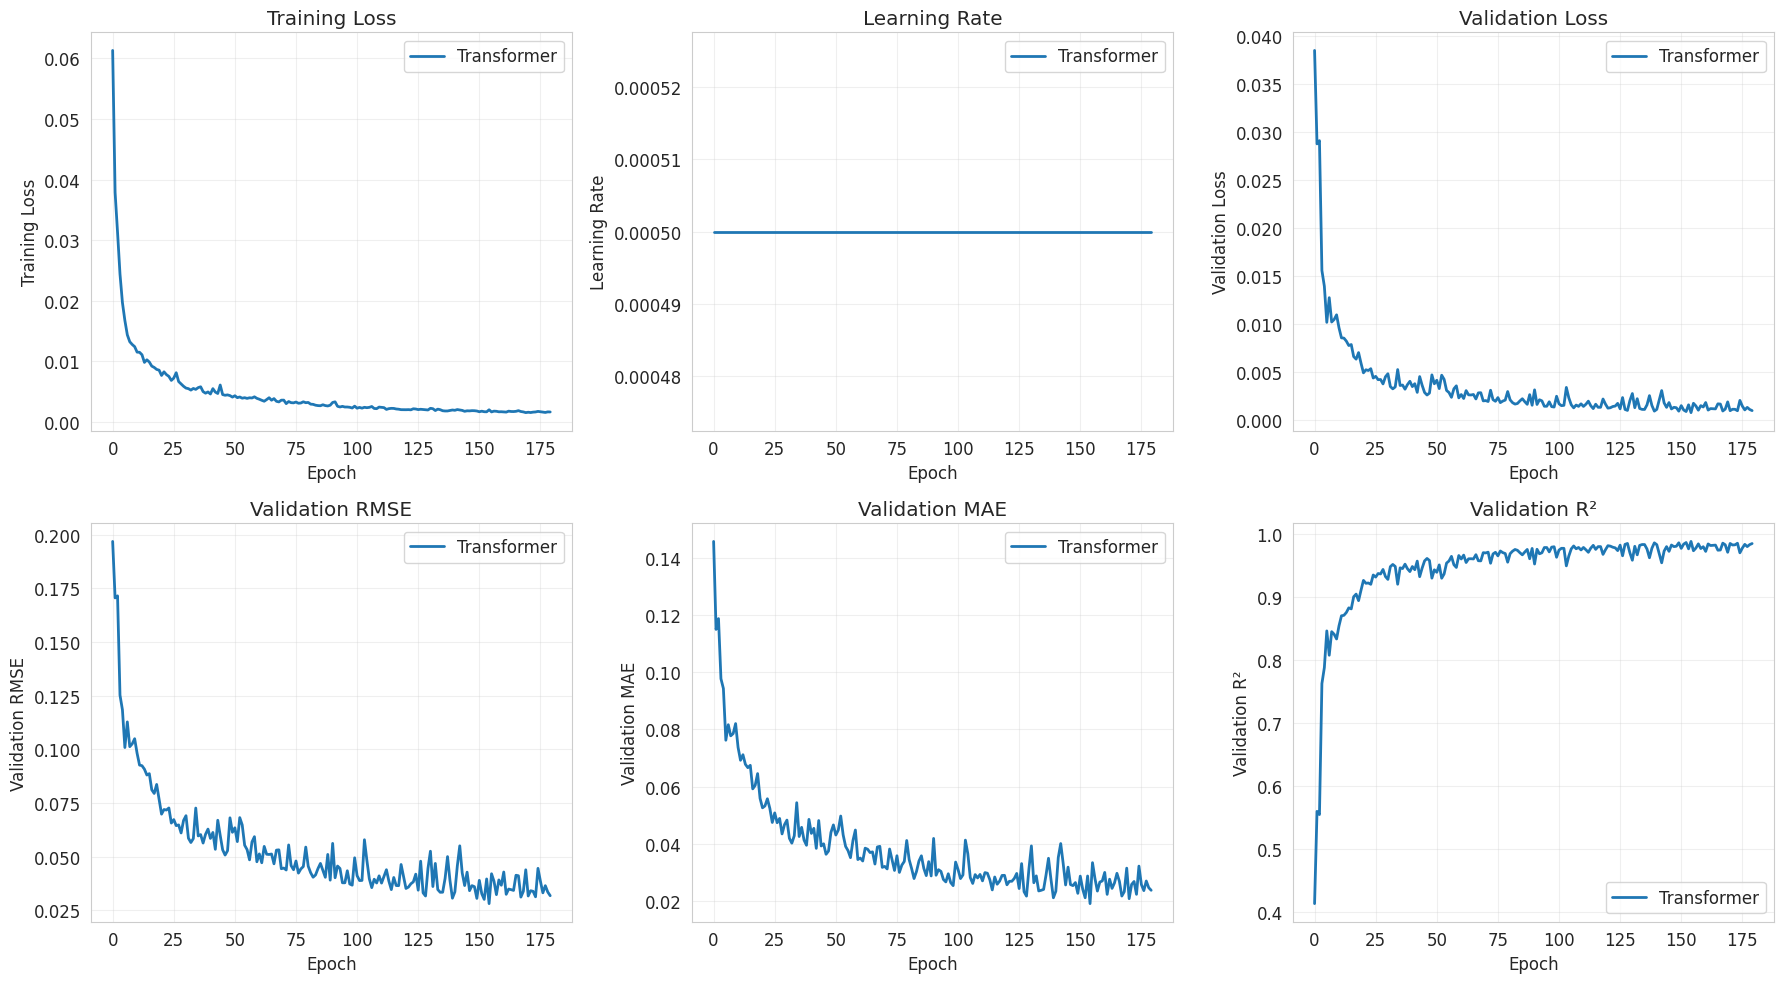

In [16]:

# Plot comparison
histories = [ transformer_history]
model_names = ['Transformer']

plot_training_history(histories, model_names)

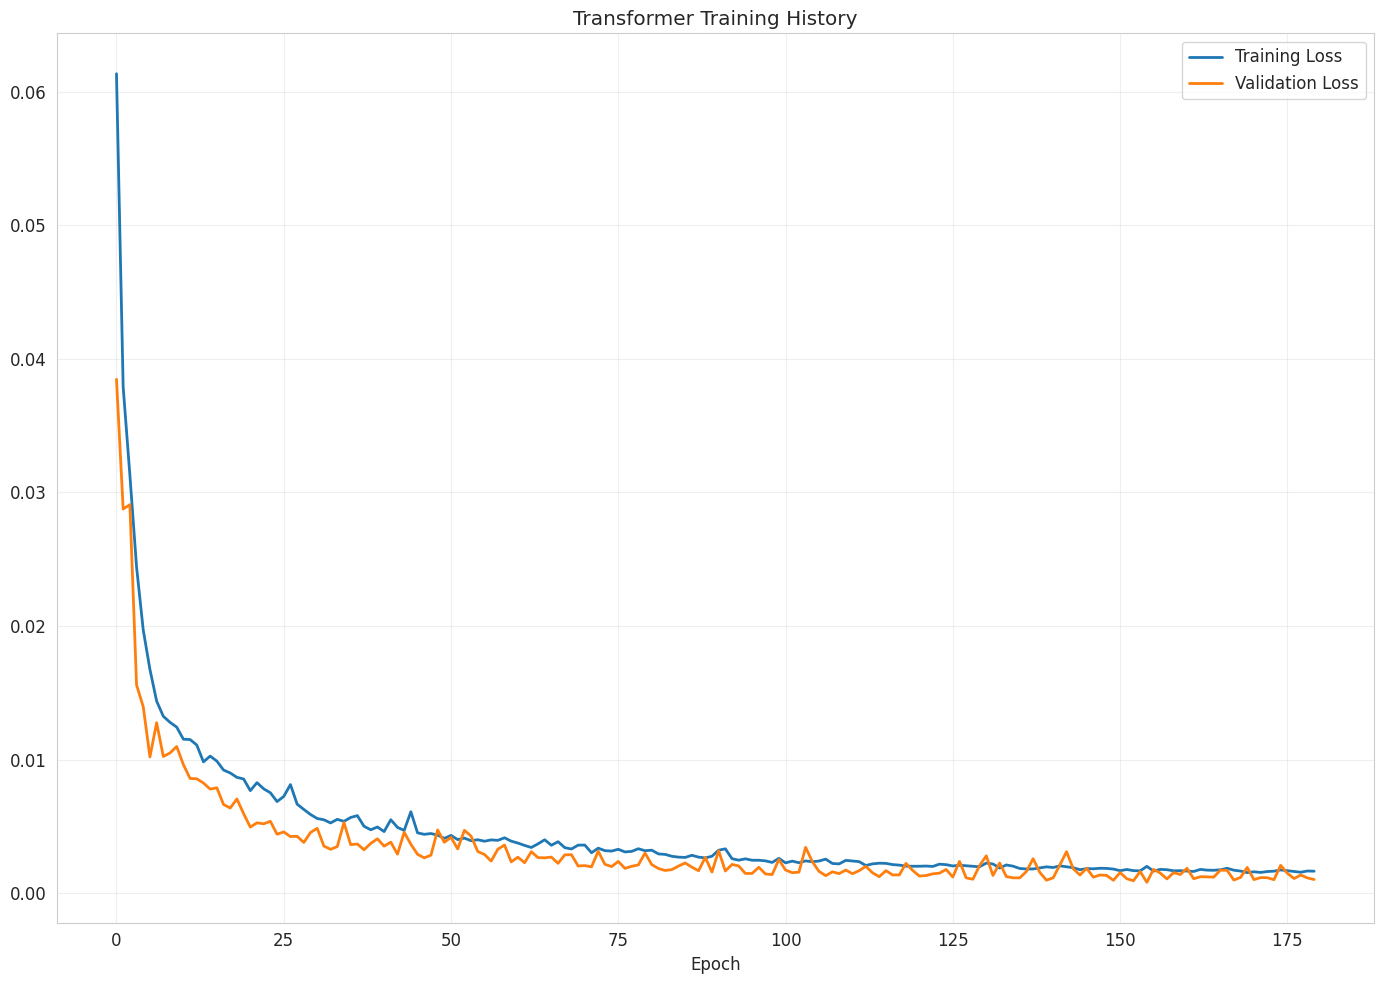

In [25]:
# plot training and validation together for transformer
def plot_transformer_history(history):
    """Plot training and validation metrics for the transformer model"""
    
    metrics = ['train_loss',  'val_loss',]
    titles = ['Training Loss',  'Validation Loss']
    
    # do a single plot
    fig, axes = plt.subplots(1, 1, figsize=(14, 10))
    for metric, title in zip(metrics, titles):
        axes.plot(history[metric], label=title, linewidth=2)
    
    axes.set_xlabel('Epoch')
    axes.set_title('Transformer Training History')
    axes.legend()
    axes.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'vizualization/transformer_training.png', dpi=300, bbox_inches='tight')
    plt.show()
   

plot_transformer_history(transformer_history)

In [38]:
# ── Evaluate on test set ─────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

seed_everything(42)

all_preds_norm_train = []
all_trues_norm_train = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device).float()
        y_batch = y_batch.to(device).float().view(-1)

        y_hat = model(X_batch).view(-1)

        all_preds_norm_train.extend(y_hat.cpu().numpy().tolist())
        all_trues_norm_train.extend(y_batch.cpu().numpy().tolist())

y_pred_norm_train = np.array(all_preds_norm_train, dtype=np.float32)
y_true_norm_train = np.array(all_trues_norm_train, dtype=np.float32)

# ── Denormalize using the fitted normalizer ──────────────────────────────────
y_pred_denorm_train = normalizer.inverse_transform_y(y_pred_norm_train)
y_true_denorm_train = normalizer.inverse_transform_y(y_true_norm_train)

# ── Metrics on denormalized values ───────────────────────────────────────────
mse_train  = mean_squared_error(y_true_denorm_train, y_pred_denorm_train)
rmse_train = np.sqrt(mse_train)
mae_train  = mean_absolute_error(y_true_denorm_train, y_pred_denorm_train)
r2_train   = r2_score(y_true_denorm_train, y_pred_denorm_train)

print("=" * 60)
print("TRAIN SET RESULTS (Denormalized RUL)")
print("=" * 60)
print(f"  MSE  : {mse_train:,.2f}")
print(f"  RMSE : {rmse_train:,.2f}")
print(f"  MAE  : {mae_train:,.2f}")
print(f"  R²   : {r2_train:.4f}")
print(f"  Samples: {len(y_true_denorm_train):,}")
print(f"  True RUL range : [{y_true_denorm_train.min():.1f}, {y_true_denorm_train.max():.1f}]")
print(f"  Pred RUL range : [{y_pred_denorm_train.min():.1f}, {y_pred_denorm_train.max():.1f}]")
print("=" * 60)

TRAIN SET RESULTS (Denormalized RUL)
  MSE  : 4,532.27
  RMSE : 67.32
  MAE  : 49.04
  R²   : 0.9911
  Samples: 6,061
  True RUL range : [0.0, 2772.0]
  Pred RUL range : [-107.0, 2892.1]


In [34]:
# ── Evaluate on test set ─────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

seed_everything(42)

all_preds_norm = []
all_trues_norm = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device).float()
        y_batch = y_batch.to(device).float().view(-1)

        y_hat = model(X_batch).view(-1)

        all_preds_norm.extend(y_hat.cpu().numpy().tolist())
        all_trues_norm.extend(y_batch.cpu().numpy().tolist())

y_pred_norm = np.array(all_preds_norm, dtype=np.float32)
y_true_norm = np.array(all_trues_norm, dtype=np.float32)

# ── Denormalize using the fitted normalizer ──────────────────────────────────
y_pred_denorm = normalizer.inverse_transform_y(y_pred_norm)
y_true_denorm = normalizer.inverse_transform_y(y_true_norm)

# ── Metrics on denormalized values ───────────────────────────────────────────
mse  = mean_squared_error(y_true_denorm, y_pred_denorm)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true_denorm, y_pred_denorm)
r2   = r2_score(y_true_denorm, y_pred_denorm)

print("=" * 60)
print("TEST SET RESULTS (Denormalized RUL)")
print("=" * 60)
print(f"  MSE  : {mse:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  MAE  : {mae:,.2f}")
print(f"  R²   : {r2:.4f}")
print(f"  Samples: {len(y_true_denorm):,}")
print(f"  True RUL range : [{y_true_denorm.min():.1f}, {y_true_denorm.max():.1f}]")
print(f"  Pred RUL range : [{y_pred_denorm.min():.1f}, {y_pred_denorm.max():.1f}]")
print("=" * 60)

TEST SET RESULTS (Denormalized RUL)
  MSE  : 639,002.31
  RMSE : 799.38
  MAE  : 650.81
  R²   : -0.5319
  Samples: 30,676
  True RUL range : [0.0, 2433.0]
  Pred RUL range : [-106.3, 2481.8]


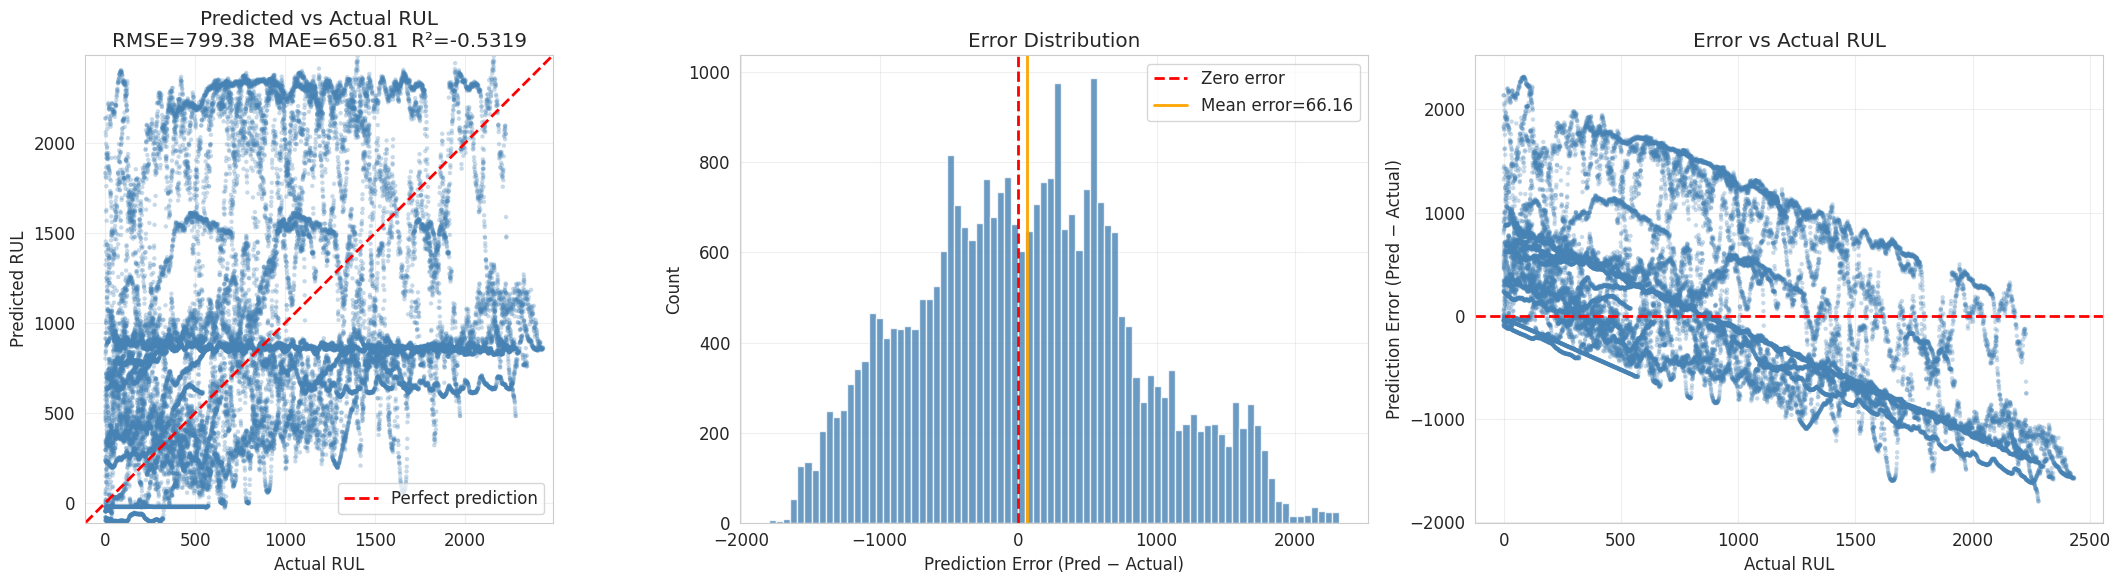

Saved to /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/vizualization/test_rul_scatter.png


In [35]:
# Cell 1: Predicted vs Actual scatter + perfect-prediction line

os.makedirs(OUTPUT_DIR / "vizualization", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── 1. Scatter: Predicted vs Actual ─────────────────────────────────────────
ax = axes[0]
ax.scatter(y_true_denorm, y_pred_denorm, alpha=0.3, s=10, c='steelblue', edgecolors='none')
lims = [
    min(y_true_denorm.min(), y_pred_denorm.min()) - 5,
    max(y_true_denorm.max(), y_pred_denorm.max()) + 5,
]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title(f'Predicted vs Actual RUL\nRMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# ── 2. Error distribution ───────────────────────────────────────────────────
ax = axes[1]
errors = y_pred_denorm - y_true_denorm
ax.hist(errors, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(errors.mean(), color='orange', linestyle='-', linewidth=2, label=f'Mean error={errors.mean():.2f}')
ax.set_xlabel('Prediction Error (Pred − Actual)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3. Error vs Actual RUL ──────────────────────────────────────────────────
ax = axes[2]
ax.scatter(y_true_denorm, errors, alpha=0.3, s=10, c='steelblue', edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Prediction Error (Pred − Actual)')
ax.set_title('Error vs Actual RUL')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vizualization/test_rul_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'vizualization/test_rul_scatter.png'}")

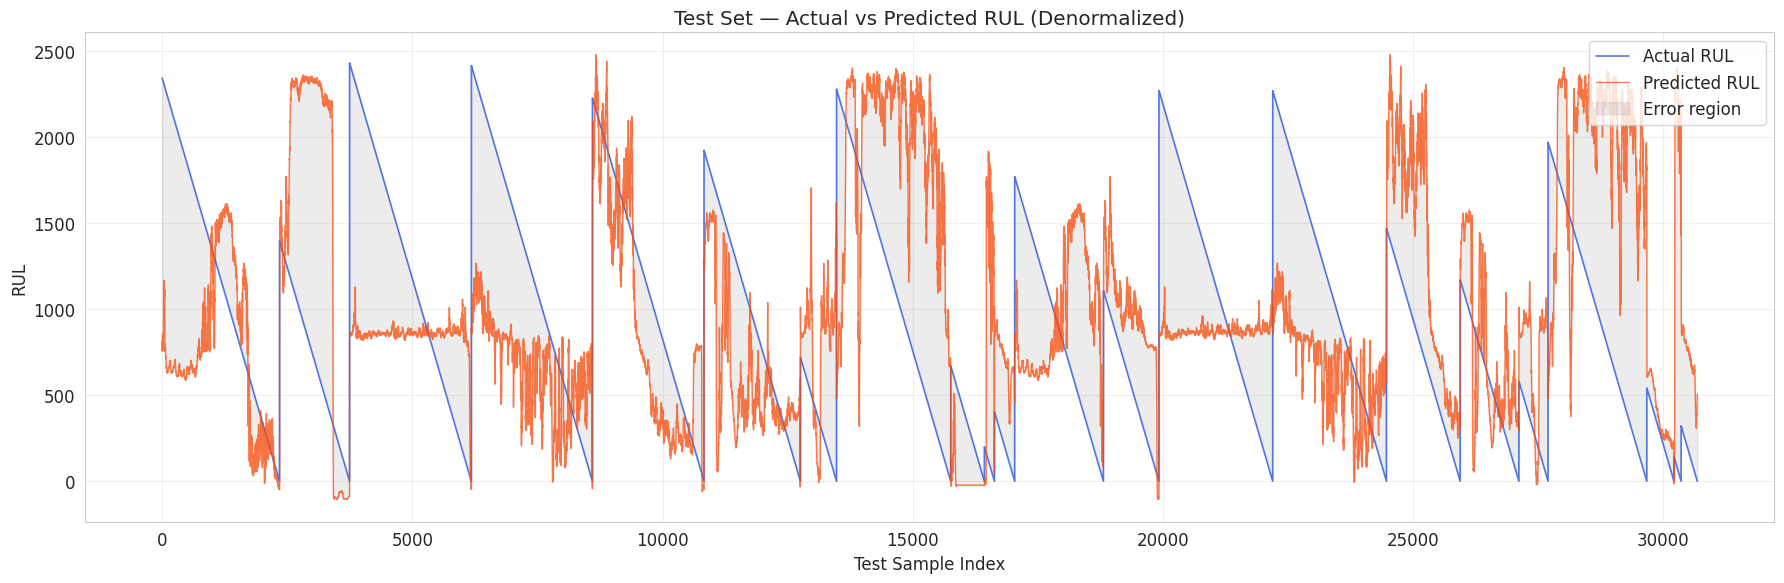

Saved to /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/vizualization/test_rul_timeseries.png


In [36]:
# Cell 2: Per-sample RUL time-series overlay (Actual vs Predicted)

fig, ax = plt.subplots(figsize=(18, 6))

sample_indices = np.arange(len(y_true_denorm))

ax.plot(sample_indices, y_true_denorm, color='royalblue', linewidth=1.2, alpha=0.9, label='Actual RUL')
ax.plot(sample_indices, y_pred_denorm, color='orangered', linewidth=1.0, alpha=0.7, label='Predicted RUL')
ax.fill_between(sample_indices, y_true_denorm, y_pred_denorm, alpha=0.15, color='gray', label='Error region')

ax.set_xlabel('Test Sample Index')
ax.set_ylabel('RUL')
ax.set_title('Test Set — Actual vs Predicted RUL (Denormalized)')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vizualization/test_rul_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'vizualization/test_rul_timeseries.png'}")

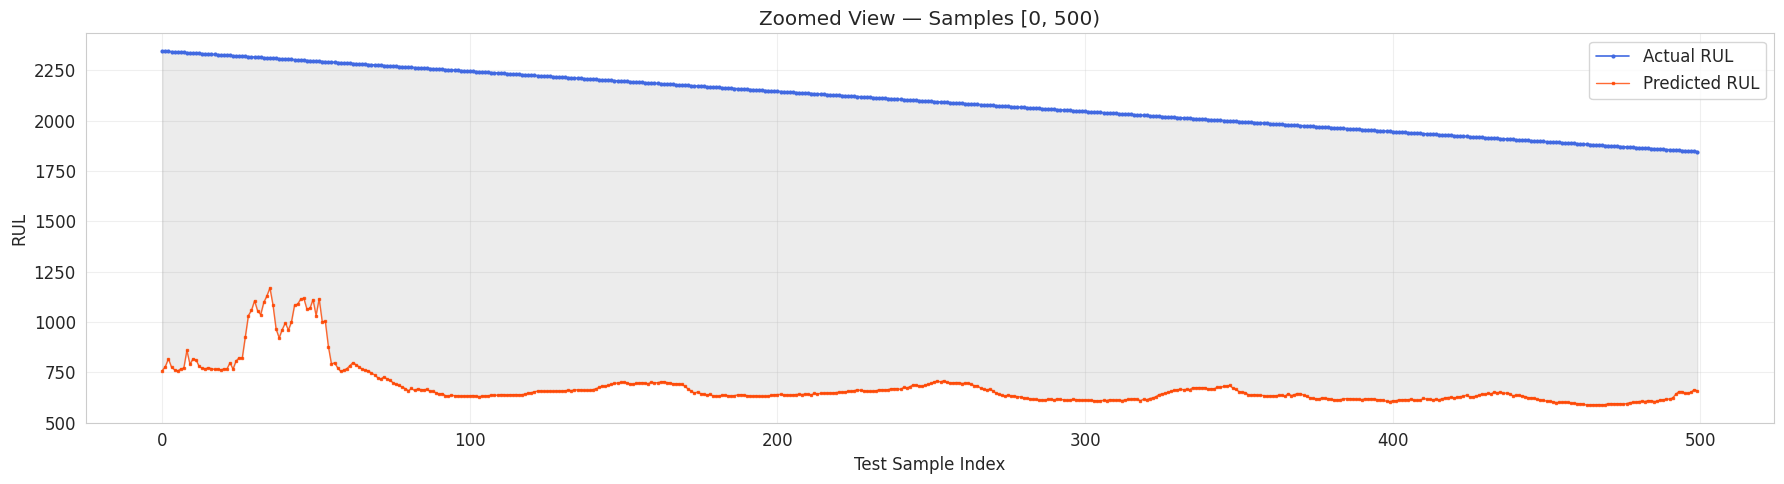

Saved to /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/vizualization/test_rul_zoomed.png


In [37]:
# Cell 3: Zoomed-in view on a subset of samples for clarity

n_zoom = min(500, len(y_true_denorm))
idx_start = 0

fig, ax = plt.subplots(figsize=(18, 5))
zoom_idx = np.arange(idx_start, idx_start + n_zoom)

ax.plot(zoom_idx, y_true_denorm[zoom_idx], 'o-', color='royalblue', markersize=2, linewidth=1.2, label='Actual RUL')
ax.plot(zoom_idx, y_pred_denorm[zoom_idx], 's-', color='orangered', markersize=2, linewidth=1.0, alpha=0.8, label='Predicted RUL')
ax.fill_between(zoom_idx, y_true_denorm[zoom_idx], y_pred_denorm[zoom_idx], alpha=0.15, color='gray')

ax.set_xlabel('Test Sample Index')
ax.set_ylabel('RUL')
ax.set_title(f'Zoomed View — Samples [{idx_start}, {idx_start + n_zoom})')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vizualization/test_rul_zoomed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'vizualization/test_rul_zoomed.png'}")